### **Nome: Jean Carlos Martins Da Silva Magalhães**

### **Matrícula: 603162**


---



In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Questão 1**

### Considere o conjunto de dados disponível em **artificial1d.csv** organizado em duas colunas, x e y. Seja um modelo de regressão linear para yˆ = f(x).

In [2]:
artificial_dataset = np.loadtxt('artificial1d.csv', delimiter=',', skiprows=1)
artificial_dataset

array([[-0.93103448, -1.32698023],
       [-0.86206897, -1.10559772],
       [-0.79310345, -0.87394576],
       [-0.72413793, -0.28502695],
       [-0.65517241, -0.43115252],
       [-0.5862069 , -0.79475402],
       [-0.51724138, -0.88606806],
       [-0.44827586, -0.89989978],
       [-0.37931034, -0.86184365],
       [-0.31034483, -0.88805183],
       [-0.24137931, -1.23595129],
       [-0.17241379, -0.71956827],
       [-0.10344828, -0.45202286],
       [-0.03448276,  0.09889951],
       [ 0.03448276,  0.34896973],
       [ 0.10344828,  0.09747797],
       [ 0.17241379,  0.70019809],
       [ 0.24137931,  1.31051213],
       [ 0.31034483,  1.00177576],
       [ 0.37931034,  1.00318231],
       [ 0.44827586,  1.14910129],
       [ 0.51724138,  1.59220607],
       [ 0.5862069 ,  0.60909009],
       [ 0.65517241,  0.59441623],
       [ 0.72413793,  0.70300732],
       [ 0.79310345,  0.82332241],
       [ 0.86206897,  1.10646439],
       [ 0.93103448,  1.42295695],
       [ 1.        ,

### a) Apresente os parâmetros do modelo e o MSE (erro quadrático médio) obtidos pelo algoritmo **OLS (mínimos quadrados ordinários)**. Plote a reta resultante sobre os dados.


Parâmetros do modelo: [[0.08956111]
 [1.51328267]]
RMSE: 0.4557547135753802
MSE: 0.20771235894617687


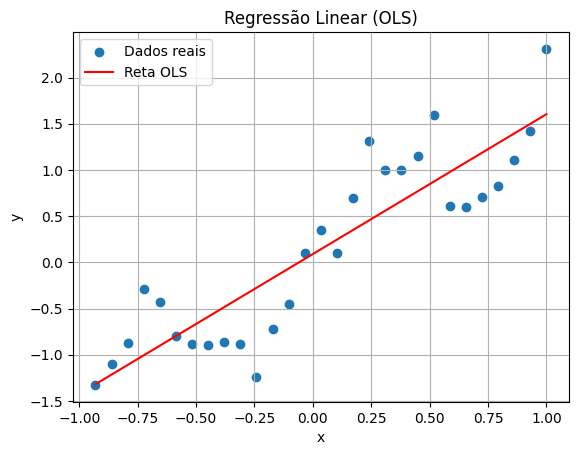

In [14]:
# Treinamento

X_data= artificial_dataset[:,[0]]
ones = np.ones((X_data.shape[0], 1))
X = np.hstack([ones, X_data])
y = artificial_dataset[:,[1]]

w = np.linalg.inv(X.T @ X) @ X.T @ y

# Predição final

estimatedY = X @ w

# Métricas

rmse= np.sqrt(np.sum((y - estimatedY) ** 2)/y.shape[0])
mse = np.sum((y - estimatedY) ** 2)/y.shape[0]
print("Parâmetros do modelo:", w)
print("RMSE:",rmse)
print("MSE:",mse)

# Plot

plt.scatter(X_data[:, 0], y, label='Dados reais')
plt.plot(X_data[:, 0], estimatedY, color='red', label='Reta OLS')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressão Linear (OLS)')
plt.legend()
plt.grid(True)
plt.show()

### b) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem obtidos pelo algoritmo **GD (gradiente descendente)**. Plote a reta resultante sobre os dados.


Parâmetros do modelo: [[0.08956431]
 [1.51319012]]
RMSE: 0.4557547167037374
MSE: 0.20771236179770391


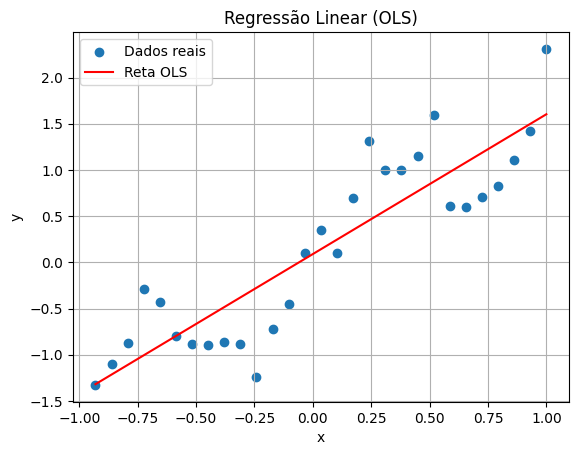

In [31]:
def normalize(arr):
    mu = np.sum(arr, axis=0)/arr.shape[0]
    sigma = np.sqrt(np.sum((arr - mu) ** 2,axis=0)/(arr.shape[0]-1))
    arrNorm = (arr - mu)/sigma
    return arrNorm, mu, sigma

# Normalização dos dados

X_data = artificial_dataset[:,[0]]
X_data_norm, X_mu, X_sigma = normalize(X_data)

ones = np.ones((X_data.shape[0], 1))
X_norm = np.hstack([ones, X_data_norm])

y = artificial_dataset[:,[1]]
y_norm, y_mu, y_sigma = normalize(y)

# Inicialização

alpha = 0.01
epochs = 1000
w = np.zeros((X_norm.shape[1],1))

# Treinamento

for t in range(epochs):
    y_pred = X_norm @ w
    error = y_norm - y_pred

    gradient = (X_norm.T @ error)/X_norm.shape[0]

    w = w + alpha * gradient

# Predição final (desnormalizada)

y_pred_norm = X_norm @ w
y_pred = y_pred_norm * y_sigma + y_mu


# Métricas

rmse= np.sqrt(np.sum((y - y_pred) ** 2)/y.shape[0])
mse = np.sum((y - y_pred) ** 2)/y.shape[0]

# Converter parâmetros

b1 = (y_sigma / X_sigma) * w[1]
b0 = y_mu + y_sigma * w[0] - b1 * X_mu

print("Parâmetros do modelo:", np.array([[b0.item()], [b1.item()]]))
print("RMSE:", rmse)
print("MSE:", mse)

# Plot

plt.scatter(artificial_dataset[:, 0], artificial_dataset[:, 1], label='Dados reais')
plt.plot(artificial_dataset[:, 0], y_pred, color='red', label='Reta OLS')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressão Linear (OLS)')
plt.legend()
plt.grid(True)
plt.show()

### c) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem obtidos pelo algoritmo **SGD (gradiente descendente estocástico)**.
### Plote a reta resultante sobre os dados.


Parâmetros do modelo: [[0.089172  ]
 [1.51194406]]
RMSE: 0.4557555759307207
MSE: 0.20771314499194293


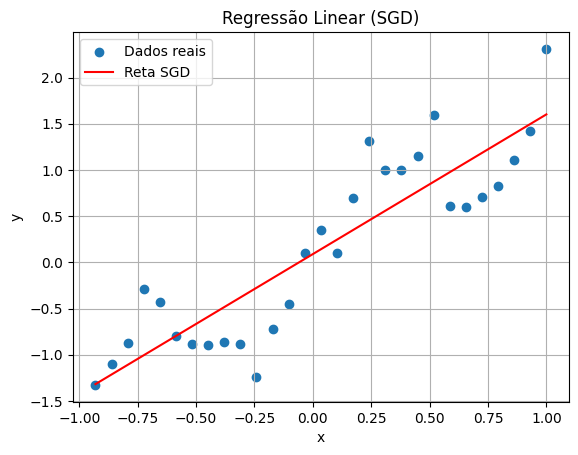

In [29]:
def normalize(arr):
    mu = np.sum(arr, axis=0)/arr.shape[0]
    sigma = np.sqrt(np.sum((arr - mu) ** 2, axis=0)/(arr.shape[0]-1))
    arrNorm = (arr - mu)/sigma
    return arrNorm, mu, sigma


# Normalização dos dados
X_data = artificial_dataset[:, [0]]
X_data_norm, X_mu, X_sigma = normalize(X_data)

ones = np.ones((X_data.shape[0], 1))
X_norm = np.hstack([ones, X_data_norm])

y = artificial_dataset[:, [1]]
y_norm, y_mu, y_sigma = normalize(y)


# Inicialização

alpha = 0.01
epochs = 1000
w = np.zeros((X_norm.shape[1], 1))

losses = []
historic_w = []

N = X_norm.shape[0]

# Treinamento (SGD)

for epoch in range(epochs):

    indices = np.random.permutation(N)

    for i in indices:
        xi = X_norm[i, :].reshape((1, -1))
        yi = y_norm[i].reshape((1, 1))

        y_pred_i = xi @ w
        error_i = yi - y_pred_i

        grad = xi.T @ error_i

        w = w + alpha * grad

    # cálculo da loss por época
    y_pred_epoch = X_norm @ w
    loss = np.mean((y_norm - y_pred_epoch) ** 2)

    losses.append(loss)
    historic_w.append(w.flatten().copy())

# Predição final (desnormalizada)

y_pred_norm = X_norm @ w
y_pred = y_pred_norm * y_sigma + y_mu

# Métricas

rmse = np.sqrt(np.mean((y - y_pred) ** 2))
mse = np.mean((y - y_pred) ** 2)

# Converter parâmetros

b1 = (y_sigma / X_sigma) * w[1]
b0 = y_mu + y_sigma * w[0] - b1 * X_mu

print("Parâmetros do modelo:", np.array([[b0.item()], [b1.item()]]))
print("RMSE:", rmse)
print("MSE:", mse)

# Plot

sorted_idx = np.argsort(X_data[:, 0])
x_sorted = X_data[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.scatter(X_data[:, 0], y, label='Dados reais')
plt.plot(x_sorted[:, 0], y_pred_sorted, color='red', label='Reta SGD')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressão Linear (SGD)')
plt.legend()
plt.grid(True)
plt.show()

### **Questão 2**

### Considere o conjunto de dados disponível em **california.csv**, organizado em 9 colunas, sendo as 8 primeiras colunas os atributos e a última coluna a saída. Os 8 atributos são usados na predição da mediana de preços de casas em distritos da Califórnia na década de 1990. Maiores detalhes sobre os dados podem ser conferidos em  https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset.


In [32]:
# Carregar o conjunto de dados da Califórnia
california_dataset = np.loadtxt('california.csv', delimiter=',', skiprows=1)
# Printar o conjunto de dados
california_dataset

array([[   2.8194    ,   24.        ,    4.7625    , ...,   36.75      ,
        -119.85      ,    0.811     ],
       [   2.425     ,   46.        ,    4.92771084, ...,   36.33      ,
        -119.31      ,    0.849     ],
       [   3.1205    ,   16.        ,    3.72847682, ...,   33.87      ,
        -117.99      ,    1.74      ],
       ...,
       [   4.7308    ,   35.        ,    5.66666667, ...,   33.83      ,
        -118.37      ,    3.534     ],
       [   4.2788    ,   10.        ,    5.375     , ...,   33.68      ,
        -117.35      ,    1.25      ],
       [   2.8036    ,   18.        ,    3.27400881, ...,   34.1       ,
        -118.35      ,    2.25      ]])

### a) Aleatoriamente, divida o conjunto de dados em treino (80%) e teste (20%).

In [33]:
# Cria uma cópia do conjunto de dados
dataset = california_dataset.copy()

# Armazena a quantidade de linhas do dataset
N = dataset.shape[0]

# Realiza a permutação dos dados
indices = np.random.permutation(N)

# Armazena a quantidade de dados de treino
tam_treino = int(0.8 * N)

# Divide o dataset em treino e teste
indices_treino = indices[:tam_treino]
indices_teste = indices[tam_treino:]
dataset_treino = dataset[indices_treino]
dataset_teste = dataset[indices_teste]

# Armazena o x e y do dataset de treino e teste
X_train = dataset_treino[:,:-1]
y_train = dataset_treino[:,-1:]
X_test = dataset_teste[:,:-1]
y_test = dataset_teste[:,-1:]

# Printar os dados de treino
X_train

array([[   4.0062    ,   12.        ,    5.69396552, ...,    2.84913793,
          39.22      , -120.94      ],
       [   2.5313    ,   42.        ,    3.91346154, ...,    3.71634615,
          34.02      , -118.16      ],
       [   2.1935    ,   31.        ,    4.79402985, ...,    3.13134328,
          34.16      , -117.34      ],
       ...,
       [   4.983     ,   30.        ,    4.91694352, ...,    3.74086379,
          37.47      , -122.13      ],
       [   1.8519    ,   52.        ,    2.65445026, ...,    2.7617801 ,
          37.78      , -122.41      ],
       [   5.1645    ,   26.        ,    5.48      , ...,    3.38545455,
          33.88      , -118.08      ]])

In [34]:
# Constrói o polinômio de grau desejado
def construir_X_polynomial(X, grau):
    # Cria uma cópia de X para armazenar os atributos polinomiais
    X_poly = X.copy()

    # Adiciona os atributos polinomiais
    for g in range(2, grau + 1):
        # Adiciona os atributos elevados a g
        X_poly = np.hstack((X_poly, X ** g))

    # Retorna o novo conjunto de dados com os atributos polinomiais
    return X_poly

In [35]:
# Adiciona uma coluna de 1s para o termo de bias
def adicionar_bias(X):
    # Armazena a quantidade de linhas do dataset
    n = X.shape[0]
    # Retorna a matriz X com uma coluna de 1s adicionada
    return np.hstack((np.ones((n, 1)), X))

In [36]:
# Treina o modelo de regressão linear OLS
def treinar_ols(X, y):
    # Retorna os pesos w do modelo de regressão linear OLS
    return np.linalg.inv(X.T @ X) @ X.T @ y

In [37]:
# Treinamento do modelo de regressão linear OLS L2
def treinar_ridge(X, y, lambd):
    # Pega o número de colunas de X e cria uma matriz identidade
    n = X.shape[1]
    # Cria uma matriz identidade de tamanho n
    I = np.eye(n)
    # Retorna os pesos do modelo de regressão linear OLS L2
    return np.linalg.inv(X.T @ X + lambd * I) @ X.T @ y

In [38]:
# Função para normalizar os dados com Min-Max
def normaliza(X):
    # Armazena o valor mínimo e máximo de cada coluna
    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)

    # Normaliza os dados para o intervalo [0, 1]
    X_norm = (X - X_min) / (X_max - X_min)

    # Retorna os dados normalizados
    return X_norm

In [39]:
# Verificando se as funções criadas estão funcionando
print(construir_X_polynomial(X_train, 2).shape)
print(construir_X_polynomial(X_train, 2))
print(normaliza(construir_X_polynomial(X_train, 2)))
print(adicionar_bias(normaliza(construir_X_polynomial(X_train, 2))))
print(adicionar_bias(normaliza(construir_X_polynomial(X_train, 2))).shape)

(799, 16)
[[4.00620000e+00 1.20000000e+01 5.69396552e+00 ... 8.11758695e+00
  1.53820840e+03 1.46264836e+04]
 [2.53130000e+00 4.20000000e+01 3.91346154e+00 ... 1.38112287e+01
  1.15736040e+03 1.39617856e+04]
 [2.19350000e+00 3.10000000e+01 4.79402985e+00 ... 9.80531076e+00
  1.16690560e+03 1.37686756e+04]
 ...
 [4.98300000e+00 3.00000000e+01 4.91694352e+00 ... 1.39940619e+01
  1.40400090e+03 1.49157369e+04]
 [1.85190000e+00 5.20000000e+01 2.65445026e+00 ... 7.62742935e+00
  1.42732840e+03 1.49842081e+04]
 [5.16450000e+00 2.60000000e+01 5.48000000e+00 ... 1.14613025e+01
  1.14785440e+03 1.39428864e+04]]
[[0.23083704 0.2        0.17093315 ... 0.07621097 0.69101551 0.61867937]
 [0.12764811 0.8        0.09986842 ... 0.1450082  0.1412586  0.29953225]
 [0.1040145  0.58       0.13501429 ... 0.09660402 0.15503717 0.2068127 ]
 ...
 [0.29917723 0.56       0.1399201  ... 0.14721741 0.49728599 0.75756102]
 [0.08011502 1.         0.04961788 ... 0.07028832 0.53095941 0.79043668]
 [0.31187558 0.48   

### b) Treine 13 modelos de **regressão polinomial**, com ordens de 1 a 13. Você pode usar o algoritmo OLS.


In [40]:
# Inicializa uma lista para armazenar os erros
rmse_train = []
rmse_test = []

# Calculando a média e a distribuição do target de treinamento
u_train = y_train.sum(axis = 0) / y_train.shape[0]
o_train = np.sqrt(((y_train-u_train)**2).sum(axis=0)/(y_train.shape[0]-1))

# Calculando a média e a distribuição do target de teste
u_test = y_test.sum(axis = 0) / y_test.shape[0]
o_test = np.sqrt(((y_test-u_test)**2).sum(axis=0)/(y_test.shape[0]-1))

# Normaliza os targets de treino e teste
y_train_norm = (y_train - u_train) / o_train
y_test_norm = (y_test - u_test) / o_test

# Função para construir a matriz de características polinomiais
for grau in range(1, 14):
    # Constrói a matriz de características polinomiais normaliza e adicionando o bias
    Xp_train = adicionar_bias(normaliza(construir_X_polynomial(X_train, grau)))
    Xp_test = adicionar_bias(normaliza(construir_X_polynomial(X_test, grau)))

    # Atuzaliza os pesos
    w = treinar_ols(Xp_train, y_train_norm)

    # Predição e desnormalização
    y_pred_train = Xp_train @ w * o_train + u_train
    y_pred_test = Xp_test @ w * o_test + u_test

    # Calcula o RMSE para treino e teste
    rmse_train.append(np.sqrt(np.mean((y_train - y_pred_train) ** 2)))
    rmse_test.append(np.sqrt(np.mean((y_test - y_pred_test) ** 2)))

### c) Reporte o **RMSE (raiz quadrada do erro quadrático médio)** no treinamento e no teste para cada modelo. Faça um gráfico para o treino e um gráfico para o teste.

RMSE treino: [np.float64(0.6816068305345944), np.float64(0.6546447166147096), np.float64(0.6282046063053565), np.float64(0.6178103391031425), np.float64(0.6178698660951456), np.float64(1.0261019191923229), np.float64(0.7240977746835313), np.float64(0.7792373699789567), np.float64(1.915257154559198), np.float64(0.6558097733807957), np.float64(1.8809952282909437), np.float64(1.7662538165436383), np.float64(1.4331925358624673)]
RMSE teste: [np.float64(0.8957202735399928), np.float64(0.7250080342145779), np.float64(0.6726229838086009), np.float64(0.8724141082808979), np.float64(1.0254482500228823), np.float64(2.1229780021026654), np.float64(4.338775412561165), np.float64(7.444445811795378), np.float64(3.405933734101093), np.float64(18.545975064883514), np.float64(86.92876759182026), np.float64(17.824764840513684), np.float64(59.713587873844965)]


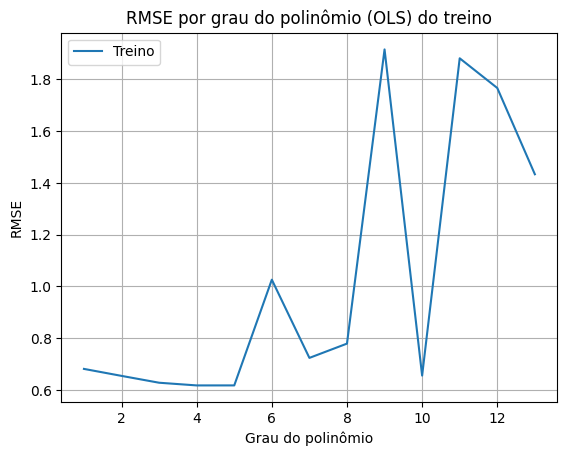

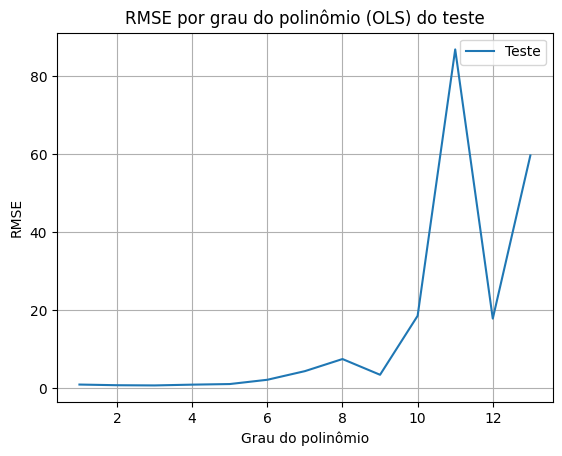

In [41]:
# Printar os RMSE de treino e teste
print("RMSE treino:", rmse_train)
print("RMSE teste:", rmse_test)

# Plotar os erros RMSE de treino
plt.plot(range(1, 14), rmse_train, label='Treino')
plt.xlabel('Grau do polinômio')
plt.ylabel('RMSE')
plt.title('RMSE por grau do polinômio (OLS) do treino')
plt.legend()
plt.grid(True)
plt.show()

# Plotar os erros RMSE de teste
plt.plot(range(1, 14), rmse_test, label='Teste')
plt.xlabel('Grau do polinômio')
plt.ylabel('RMSE')
plt.title('RMSE por grau do polinômio (OLS) do teste')
plt.legend()
plt.grid(True)
plt.show()

### d) Repita os 2 itens anteriores incluindo um termo de **regularização L2** (por exemplo, com fator λ = 0.01).

RMSE treino: [np.float64(0.6816136445567192), np.float64(0.6565926083943678), np.float64(0.6444870705816995), np.float64(0.6415778339362548), np.float64(0.6400616257478804), np.float64(0.638827311287183), np.float64(0.6377362824768875), np.float64(0.6369263699335723), np.float64(0.636303641247378), np.float64(0.6358240389226287), np.float64(0.6354440351104543), np.float64(0.6351534175735696), np.float64(0.6349282938400509)]
RMSE teste: [np.float64(0.8941478924610461), np.float64(0.7061886988194532), np.float64(0.6625607516043028), np.float64(0.6459220678635036), np.float64(0.6518594337753961), np.float64(0.6649078362621491), np.float64(0.6751399166700272), np.float64(0.6792578490614026), np.float64(0.6780609569261726), np.float64(0.6745032155888837), np.float64(0.6711597826392541), np.float64(0.669350505012852), np.float64(0.6693080809435681)]


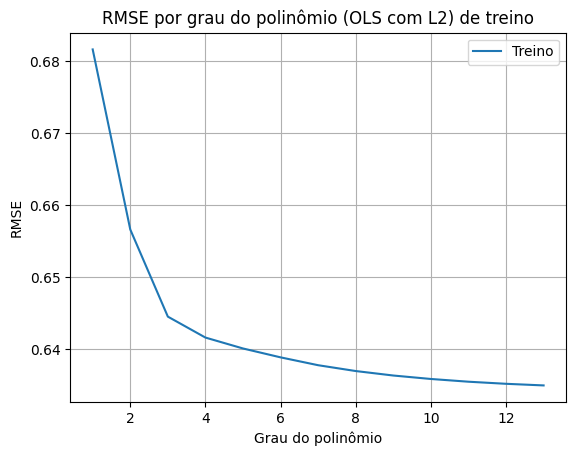

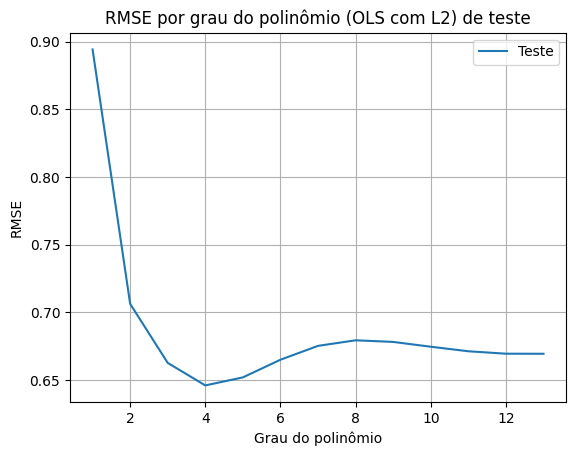

In [42]:
# Inicializa uma lista para armazenar os erros
rmse_train = []
rmse_test = []

lambd = 0.01

# Executa o treinamento do modelo de regressão polinomial para cada polinômio com regularização L2 (Ridge)
for grau in range(1, 14):
    # Constrói a matriz de características polinomiais normaliza e adicionando o bias
    Xp_train = adicionar_bias(normaliza(construir_X_polynomial(X_train, grau)))
    Xp_test = adicionar_bias(normaliza(construir_X_polynomial(X_test, grau)))

    # Atuzaliza os pesos
    w = treinar_ridge(Xp_train, y_train_norm,lambd)

    # Predição e desnormalização
    y_pred_train = Xp_train @ w * o_train + u_train
    y_pred_test = Xp_test @ w * o_test + u_test

    # armazena o RMSE para treino e teste
    rmse_train.append(np.sqrt(np.mean((y_train - y_pred_train) ** 2)))
    rmse_test.append(np.sqrt(np.mean((y_test - y_pred_test) ** 2)))

# Printar o RMSE de treino e teste
print("RMSE treino:", rmse_train)
print("RMSE teste:", rmse_test)

# Plotar os erros RMSE de treino
plt.plot(range(1, 14), rmse_train, label='Treino')
plt.xlabel('Grau do polinômio')
plt.ylabel('RMSE')
plt.title('RMSE por grau do polinômio (OLS com L2) de treino')
plt.legend()
plt.grid(True)
plt.show()

# Plotar os erros RMSE de teste
plt.plot(range(1, 14), rmse_test, label='Teste')
plt.xlabel('Grau do polinômio')
plt.ylabel('RMSE')
plt.title('RMSE por grau do polinômio (OLS com L2) de teste')
plt.legend()
plt.grid(True)
plt.show()